# Stage 2: TF–IDF Reliability Baseline  
# 第二阶段：TF–IDF 可靠性基线

This notebook builds the first reproducible modeling baseline for the Russian corporate RAG reliability task.  
本笔记本为俄语企业级 RAG 可靠性任务构建第一个可复现的建模基线。

## Goals / 目标

1. Establish majority-class lower bounds. / 建立多数类下界。
2. Compare four text representations. / 比较四种文本表示。
3. Train separate classifiers for relevancy, faithfulness, and joint reliability. / 分别训练相关性、忠实性和联合可靠性分类器。
4. Compare direct reliability prediction with the decomposed rule  
   $(\widehat{reliable}=\widehat{relevant}\land\widehat{faithful})$.  
   比较直接可靠性预测与分解规则。
5. Tune hyperparameters and thresholds **only on validation data**, then evaluate the selected models once on the test set.  
   仅在验证集上调整超参数和阈值，随后在测试集上对选定模型进行一次最终评估。

## Important protocol / 重要协议

- The fixed Stage-1 splits are used without modification. / 不修改第一阶段固定的数据划分。
- The test labels are not used during model selection. / 模型选择期间不使用测试标签。
- `markers` are not used as model inputs because they are unavailable for most production cases. / 不将 `markers` 用作模型输入，因为大多数生产样本中不可用。
- Different answers for the same dialogue remain in the same split because Stage 1 used dialogue-grouped splitting. / 同一对话的不同回答仍位于同一数据划分中，因为第一阶段采用了按对话分组的划分方式。

## 1. Imports and configuration / 导入与配置

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TARGETS = {
    "relevancy": "binary_relevancy",
    "faithfulness": "binary_faithfulness",
    "reliability": "binary_reliability",
}

# Search for the project root so the notebook works both from the root
# directory and from the notebooks/ directory.
# 自动查找项目根目录，使笔记本可从根目录或 notebooks/ 目录运行。
root_candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(
    (path for path in root_candidates if (path / "processed" / "train.csv").exists()),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Could not find processed/train.csv. Run Stage 1 first. "
        "/ 未找到 processed/train.csv，请先运行第一阶段。"
    )

PROCESSED_DIR = ROOT / "processed"
RESULTS_DIR = ROOT / "results" / "stage2_tfidf"
MODELS_DIR = RESULTS_DIR / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root / 项目根目录: {ROOT.resolve()}")
print(f"Results directory / 结果目录: {RESULTS_DIR.resolve()}")

Project root / 项目根目录: /content
Results directory / 结果目录: /content/results/stage2_tfidf


## 2. Load and validate the fixed splits / 加载并验证固定划分

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

required_columns = {
    "case_id",
    "question",
    "full_dialog",
    "answer",
    "binary_relevancy",
    "binary_faithfulness",
    "binary_reliability",
    "dialog_group_id",
    "retrieval_config",
    *[f"chunk_{i}" for i in range(1, 9)],
}

for split_name, frame in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    missing = required_columns - set(frame.columns)
    if missing:
        raise ValueError(
            f"Missing columns in {split_name}: {sorted(missing)} "
            f"/ {split_name} 中缺少列: {sorted(missing)}"
        )

    for target_column in TARGETS.values():
        frame[target_column] = frame[target_column].astype(int)

# Verify that dialogue groups do not overlap across splits.
# 验证不同划分之间不存在对话组重叠。
train_groups = set(train_df["dialog_group_id"])
val_groups = set(val_df["dialog_group_id"])
test_groups = set(test_df["dialog_group_id"])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

split_overview = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "relevancy_positive_rate": frame["binary_relevancy"].mean(),
            "faithfulness_positive_rate": frame["binary_faithfulness"].mean(),
            "reliability_positive_rate": frame["binary_reliability"].mean(),
            "top_5_rate": (frame["retrieval_config"] == "top_5").mean(),
            "top_8_rate": (frame["retrieval_config"] == "top_8").mean(),
        }
        for name, frame in [
            ("train", train_df),
            ("validation", val_df),
            ("test", test_df),
        ]
    ]
)

display(split_overview.round(4))
print("Dialogue leakage check passed. / 对话泄漏检查已通过。")

,split,rows,relevancy_positive_rate,faithfulness_positive_rate,reliability_positive_rate,top_5_rate,top_8_rate
0,train,1450,0.8738,0.7303,0.7186,0.8234,0.1766
1,validation,290,0.8724,0.7345,0.7207,0.8172,0.1828
2,test,290,0.8724,0.7345,0.7207,0.8241,0.1759


Dialogue leakage check passed. / 对话泄漏检查已通过。


## 3. Build text representations / 构建文本表示

We compare four inputs because relevancy and faithfulness depend on different information.  
我们比较四种输入，因为相关性与忠实性依赖不同的信息。

| Representation | Content | Main motivation |
|---|---|---|
| `question_answer` | extracted question + answer | relevance signal / 相关性信号 |
| `answer_context` | answer + retrieved chunks | faithfulness signal / 忠实性信号 |
| `question_answer_context` | question + answer + chunks | compact complete input / 紧凑完整输入 |
| `full_dialog_answer_context` | full dialogue + answer + chunks | tests whether full history helps / 检验完整历史是否有帮助 |

The chunk order is preserved because it corresponds to cross-encoder ranking.  
保留文本块顺序，因为它对应 cross-encoder 的排序。

In [3]:
CHUNK_COLUMNS = [f"chunk_{i}" for i in range(1, 9)]


def clean_text(value: object) -> str:
    """Convert missing values to empty strings. / 将缺失值转换为空字符串。"""
    if pd.isna(value):
        return ""
    return str(value).strip()


def join_context(row: pd.Series) -> str:
    """Join non-empty chunks while preserving their rank. / 按排名拼接非空文本块。"""
    chunks = []
    for index, column in enumerate(CHUNK_COLUMNS, start=1):
        text = clean_text(row[column])
        if text:
            chunks.append(f"[CHUNK_{index}]\n{text}")
    return "\n\n".join(chunks)


def build_text_representations(frame: pd.DataFrame) -> pd.DataFrame:
    """Create all text variants used in the ablation. / 创建消融实验所需的全部文本变体。"""
    result = pd.DataFrame(index=frame.index)
    context = frame.apply(join_context, axis=1)

    question = frame["question"].map(clean_text)
    full_dialog = frame["full_dialog"].map(clean_text)
    answer = frame["answer"].map(clean_text)

    result["question_answer"] = (
        "[QUESTION]\n" + question + "\n\n[ANSWER]\n" + answer
    )
    result["answer_context"] = (
        "[ANSWER]\n" + answer + "\n\n[CONTEXT]\n" + context
    )
    result["question_answer_context"] = (
        "[QUESTION]\n" + question
        + "\n\n[ANSWER]\n" + answer
        + "\n\n[CONTEXT]\n" + context
    )
    result["full_dialog_answer_context"] = (
        "[FULL_DIALOG]\n" + full_dialog
        + "\n\n[ANSWER]\n" + answer
        + "\n\n[CONTEXT]\n" + context
    )
    return result


train_texts = build_text_representations(train_df)
val_texts = build_text_representations(val_df)
test_texts = build_text_representations(test_df)

TEXT_VARIANTS = list(train_texts.columns)

preview = pd.DataFrame({
    "variant": TEXT_VARIANTS,
    "example_length_chars": [len(train_texts.iloc[0][variant]) for variant in TEXT_VARIANTS],
})
display(preview)

,variant,example_length_chars
0,question_answer,563
1,answer_context,7650
2,question_answer_context,7707
3,full_dialog_answer_context,8025


## 4. Evaluation helpers / 评估辅助函数

In [4]:
def binary_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Compute metrics with special attention to the unreliable class (0).
    计算指标，并特别关注不可靠类别（0）。
    """
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_negative": precision[0],
        "recall_negative": recall[0],
        "f1_negative": f1[0],
        "precision_positive": precision[1],
        "recall_positive": recall[1],
        "f1_positive": f1[1],
    }


def find_best_threshold(
    y_true: np.ndarray,
    probabilities: np.ndarray,
    thresholds: np.ndarray | None = None,
) -> tuple[float, dict[str, float]]:
    """Select a threshold using validation macro-F1 only.
    The threshold scan is vectorized for fast repeated model selection.

    仅使用验证集 macro-F1 选择阈值。
    阈值扫描采用向量化实现，以加速重复模型选择。
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.10, 0.91, 0.01), 2)

    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = probabilities[:, None] >= thresholds[None, :]
    positives = y_true[:, None] == 1
    negatives = ~positives

    tp = np.sum(predictions & positives, axis=0)
    fp = np.sum(predictions & negatives, axis=0)
    fn = np.sum((~predictions) & positives, axis=0)
    tn = np.sum((~predictions) & negatives, axis=0)

    f1_positive = np.divide(
        2 * tp,
        2 * tp + fp + fn,
        out=np.zeros_like(tp, dtype=float),
        where=(2 * tp + fp + fn) != 0,
    )
    f1_negative = np.divide(
        2 * tn,
        2 * tn + fp + fn,
        out=np.zeros_like(tn, dtype=float),
        where=(2 * tn + fp + fn) != 0,
    )
    macro_f1 = (f1_positive + f1_negative) / 2

    best_value = macro_f1.max()
    tied = np.flatnonzero(np.isclose(macro_f1, best_value))
    best_index = tied[np.argmin(np.abs(thresholds[tied] - 0.5))]
    best_threshold = float(thresholds[best_index])
    best_predictions = predictions[:, best_index].astype(int)

    return best_threshold, binary_metrics(y_true, best_predictions)


def print_report(title: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## 5. Majority-class baselines / 多数类基线

These baselines reveal how misleading accuracy can be on imbalanced labels.  
这些基线展示了在标签不平衡时准确率可能具有误导性。

In [5]:
majority_rows = []

for target_name, target_column in TARGETS.items():
    majority_class = int(train_df[target_column].mode().iloc[0])

    for split_name, frame in [("validation", val_df), ("test", test_df)]:
        y_true = frame[target_column].to_numpy()
        y_pred = np.full(len(frame), majority_class, dtype=int)

        row = {
            "method": "majority",
            "target": target_name,
            "split": split_name,
            "majority_class": majority_class,
            **binary_metrics(y_true, y_pred),
        }
        majority_rows.append(row)

majority_results = pd.DataFrame(majority_rows)
display(
    majority_results[
        ["target", "split", "majority_class", "accuracy", "f1_macro", "recall_negative"]
    ].round(4)
)

,target,split,majority_class,accuracy,f1_macro,recall_negative
0,relevancy,validation,1,0.8724,0.4659,0.0
1,relevancy,test,1,0.8724,0.4659,0.0
2,faithfulness,validation,1,0.7345,0.4235,0.0
3,faithfulness,test,1,0.7345,0.4235,0.0
4,reliability,validation,1,0.7207,0.4188,0.0
5,reliability,test,1,0.7207,0.4188,0.0


## 6. TF–IDF feature extraction / TF–IDF 特征提取

Each representation uses word unigrams and bigrams. This is a deliberately transparent and computationally efficient first baseline. Character features can be added later as a separate ablation.  
每种表示均使用词级一元和二元 n-gram。这是一个有意保持透明且计算高效的首个基线；字符特征可在后续作为单独消融实验加入。

The vectorizers are fitted on the training set only.  
向量化器仅在训练集上拟合。

In [6]:
def make_vectorizer() -> TfidfVectorizer:
    """Create a word-level TF-IDF vectorizer. / 创建词级 TF-IDF 向量化器。"""
    return TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30_000,
        sublinear_tf=True,
        lowercase=True,
        dtype=np.float32,
    )


feature_store = {}

for variant in TEXT_VARIANTS:
    print(f"Vectorizing {variant} / 正在向量化 {variant} ...")
    vectorizer = make_vectorizer()

    X_train = vectorizer.fit_transform(train_texts[variant])
    X_val = vectorizer.transform(val_texts[variant])
    X_test = vectorizer.transform(test_texts[variant])

    feature_store[variant] = {
        "vectorizer": vectorizer,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
    }

    print(
        f"  train shape={X_train.shape}, non-zero={X_train.nnz:,} "
        f"/ 训练矩阵形状={X_train.shape}, 非零元素={X_train.nnz:,}"
    )

Vectorizing question_answer / 正在向量化 question_answer ...
  train shape=(1450, 14749), non-zero=133,726 / 训练矩阵形状=(1450, 14749), 非零元素=133,726
Vectorizing answer_context / 正在向量化 answer_context ...
  train shape=(1450, 30000), non-zero=1,003,160 / 训练矩阵形状=(1450, 30000), 非零元素=1,003,160
Vectorizing question_answer_context / 正在向量化 question_answer_context ...
  train shape=(1450, 30000), non-zero=1,011,742 / 训练矩阵形状=(1450, 30000), 非零元素=1,011,742
Vectorizing full_dialog_answer_context / 正在向量化 full_dialog_answer_context ...
  train shape=(1450, 30000), non-zero=1,131,153 / 训练矩阵形状=(1450, 30000), 非零元素=1,131,153


## 7. Validation model selection / 验证集模型选择

For each target and text representation, we tune:

- SGD logistic regularization `alpha`; / SGD 逻辑分类器正则化参数 `alpha`；
- class weighting; / 类别权重；
- decision threshold selected by validation macro-F1. / 依据验证集 macro-F1 选择决策阈值。

`SGDClassifier(loss="log_loss")` is a linear logistic classifier trained by stochastic gradient descent. It is much faster than exact logistic-regression solvers on long RAG contexts while preserving the same linear decision form.  
`SGDClassifier(loss="log_loss")` 是使用随机梯度下降训练的线性逻辑分类器。对于较长的 RAG 上下文，它比精确逻辑回归求解器快得多，同时保留相同的线性决策形式。

No test metric is calculated in this section.  
本节不计算任何测试集指标。

In [7]:
ALPHA_VALUES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
CLASS_WEIGHTS = [None, "balanced"]

validation_rows = []

for variant in TEXT_VARIANTS:
    X_train = feature_store[variant]["X_train"]
    X_val = feature_store[variant]["X_val"]

    for target_name, target_column in TARGETS.items():
        y_train = train_df[target_column].to_numpy()
        y_val = val_df[target_column].to_numpy()

        for alpha in ALPHA_VALUES:
            for class_weight in CLASS_WEIGHTS:
                model = SGDClassifier(
                    loss="log_loss",
                    alpha=alpha,
                    class_weight=class_weight,
                    max_iter=2_000,
                    tol=1e-4,
                    random_state=SEED,
                )
                model.fit(X_train, y_train)

                val_probabilities = model.predict_proba(X_val)[:, 1]
                threshold, metrics = find_best_threshold(y_val, val_probabilities)

                validation_rows.append({
                    "variant": variant,
                    "target": target_name,
                    "alpha": alpha,
                    "class_weight": "none" if class_weight is None else class_weight,
                    "threshold": threshold,
                    **metrics,
                })

validation_grid_results = pd.DataFrame(validation_rows)
validation_grid_results.to_csv(
    RESULTS_DIR / "validation_grid_results.csv",
    index=False,
)

print(
    "Validation search completed. / 验证集搜索已完成。",
    f"Configurations evaluated / 已评估配置数: {len(validation_grid_results)}",
)

for target_name in TARGETS:
    print(f"\nTop validation configurations for {target_name} / {target_name} 的最佳验证配置")
    display(
        validation_grid_results[
            validation_grid_results["target"] == target_name
        ]
        .sort_values(
            ["f1_macro", "recall_negative"],
            ascending=False,
        )
        .head(8)
        .reset_index(drop=True)
        .round(4)
    )

Validation search completed. / 验证集搜索已完成。 Configurations evaluated / 已评估配置数: 120

Top validation configurations for relevancy / relevancy 的最佳验证配置


,variant,target,alpha,class_weight,threshold,accuracy,f1_macro,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,question_answer,relevancy,0.0000,balanced,0.72,0.8483,0.6511,0.4000,0.3784,0.3889,0.9098,0.9170,0.9134
1,question_answer,relevancy,0.0000,balanced,0.68,0.8517,0.6275,0.3929,0.2973,0.3385,0.9008,0.9328,0.9165
2,question_answer,relevancy,0.0001,balanced,0.67,0.8172,0.6274,0.3261,0.4054,0.3614,0.9098,0.8775,0.8934
3,question_answer,relevancy,0.0000,none,0.87,0.8310,0.6248,0.3421,0.3514,0.3467,0.9048,0.9012,0.9030
4,question_answer,relevancy,0.0000,none,0.89,0.8483,0.6136,0.3704,0.2703,0.3125,0.8973,0.9328,0.9147
5,question_answer,relevancy,0.0003,none,0.83,0.8379,0.6134,0.3438,0.2973,0.3188,0.8992,0.9170,0.9080
6,question_answer,relevancy,0.0001,none,0.84,0.8241,0.6095,0.3158,0.3243,0.3200,0.9008,0.8972,0.8990
7,question_answer,relevancy,0.0003,balanced,0.60,0.7897,0.6094,0.2857,0.4324,0.3441,0.9103,0.8419,0.8747



Top validation configurations for faithfulness / faithfulness 的最佳验证配置


,variant,target,alpha,class_weight,threshold,accuracy,f1_macro,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,question_answer,faithfulness,0.0001,balanced,0.54,0.6862,0.6058,0.4146,0.4416,0.4277,0.7933,0.7746,0.7838
1,question_answer,faithfulness,0.0001,none,0.70,0.6793,0.6002,0.4048,0.4416,0.4224,0.7913,0.7653,0.7780
2,question_answer,faithfulness,0.0003,balanced,0.52,0.6690,0.5919,0.3908,0.4416,0.4146,0.7882,0.7512,0.7692
3,question_answer,faithfulness,0.0000,balanced,0.67,0.6793,0.5872,0.3947,0.3896,0.3922,0.7804,0.7840,0.7822
4,question_answer,faithfulness,0.0003,none,0.67,0.6931,0.5870,0.4091,0.3506,0.3776,0.7768,0.8169,0.7963
5,question_answer,faithfulness,0.0000,balanced,0.68,0.6517,0.5867,0.3776,0.4805,0.4229,0.7917,0.7136,0.7506
6,question_answer,faithfulness,0.0000,none,0.79,0.6483,0.5840,0.3737,0.4805,0.4205,0.7906,0.7089,0.7475
7,question_answer,faithfulness,0.0010,balanced,0.50,0.6586,0.5837,0.3778,0.4416,0.4072,0.7850,0.7371,0.7603



Top validation configurations for reliability / reliability 的最佳验证配置


,variant,target,alpha,class_weight,threshold,accuracy,f1_macro,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,question_answer,reliability,0.0003,balanced,0.51,0.6793,0.6002,0.4250,0.4198,0.4224,0.7762,0.7799,0.7780
1,question_answer,reliability,0.0003,none,0.68,0.6621,0.5950,0.4066,0.4568,0.4302,0.7789,0.7416,0.7598
2,full_dialog_answer_context,reliability,0.0000,none,0.54,0.7034,0.5911,0.4561,0.3210,0.3768,0.7639,0.8517,0.8054
3,question_answer,reliability,0.0001,none,0.72,0.6379,0.5880,0.3889,0.5185,0.4444,0.7857,0.6842,0.7315
4,question_answer,reliability,0.0001,balanced,0.58,0.6345,0.5874,0.3874,0.5309,0.4479,0.7877,0.6746,0.7268
5,question_answer,reliability,0.0000,none,0.69,0.6793,0.5872,0.4167,0.3704,0.3922,0.7661,0.7990,0.7822
6,full_dialog_answer_context,reliability,0.0001,none,0.62,0.6793,0.5872,0.4167,0.3704,0.3922,0.7661,0.7990,0.7822
7,question_answer,reliability,0.0000,balanced,0.58,0.6759,0.5845,0.4110,0.3704,0.3896,0.7650,0.7943,0.7793


## 8. Select one model per target / 为每个目标选择一个模型

The best configuration is selected by validation macro-F1, with negative-class recall as the first tie-breaker.  
最佳配置依据验证集 macro-F1 选择，若相同则优先考虑负类召回率。

In [8]:
best_configs = {}

for target_name in TARGETS:
    candidates = validation_grid_results[
        validation_grid_results["target"] == target_name
    ].sort_values(
        ["f1_macro", "recall_negative", "accuracy"],
        ascending=False,
    )

    best_configs[target_name] = candidates.iloc[0].to_dict()

best_configs_df = pd.DataFrame(best_configs).T.reset_index(names="selected_target")
display(best_configs_df.round(4))

with open(RESULTS_DIR / "best_configs.json", "w", encoding="utf-8") as file:
    json.dump(best_configs, file, ensure_ascii=False, indent=2)

,selected_target,variant,target,alpha,class_weight,threshold,accuracy,f1_macro,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,relevancy,question_answer,relevancy,0.00001,balanced,0.72,0.848276,0.651137,0.4,0.378378,0.388889,0.909804,0.916996,0.913386
1,faithfulness,question_answer,faithfulness,0.0001,balanced,0.54,0.686207,0.60576,0.414634,0.441558,0.427673,0.793269,0.774648,0.783848
2,reliability,question_answer,reliability,0.0003,balanced,0.51,0.67931,0.600202,0.425,0.419753,0.42236,0.77619,0.779904,0.778043


## 9. Fit selected models and evaluate the test set once / 拟合选定模型并仅评估一次测试集

The selected models are refitted on the original training split using the chosen hyperparameters. The validation thresholds remain fixed.  
使用选定超参数在原始训练集上重新拟合模型，并保持验证集上选择的阈值不变。

In [9]:
selected_models = {}
validation_predictions = pd.DataFrame({"case_id": val_df["case_id"].values})
test_predictions = pd.DataFrame({"case_id": test_df["case_id"].values})
selected_metric_rows = []

for target_name, target_column in TARGETS.items():
    config = best_configs[target_name]
    variant = config["variant"]
    class_weight = None if config["class_weight"] == "none" else config["class_weight"]
    threshold = float(config["threshold"])

    X_train = feature_store[variant]["X_train"]
    X_val = feature_store[variant]["X_val"]
    X_test = feature_store[variant]["X_test"]

    y_train = train_df[target_column].to_numpy()
    y_val = val_df[target_column].to_numpy()
    y_test = test_df[target_column].to_numpy()

    model = SGDClassifier(
        loss="log_loss",
        alpha=float(config["alpha"]),
        class_weight=class_weight,
        max_iter=2_000,
        tol=1e-4,
        random_state=SEED,
    )
    model.fit(X_train, y_train)

    val_scores = model.predict_proba(X_val)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]
    val_preds = (val_scores >= threshold).astype(int)
    test_preds = (test_scores >= threshold).astype(int)

    selected_models[target_name] = {
        "model": model,
        "vectorizer": feature_store[variant]["vectorizer"],
        "variant": variant,
        "threshold": threshold,
        "target_column": target_column,
    }

    validation_predictions[f"{target_name}_score"] = val_scores
    validation_predictions[f"{target_name}_pred"] = val_preds
    test_predictions[f"{target_name}_score"] = test_scores
    test_predictions[f"{target_name}_pred"] = test_preds

    for split_name, y_true, y_pred in [
        ("validation", y_val, val_preds),
        ("test", y_test, test_preds),
    ]:
        selected_metric_rows.append({
            "method": "tfidf_logistic_selected",
            "target": target_name,
            "split": split_name,
            "variant": variant,
            "threshold": threshold,
            **binary_metrics(y_true, y_pred),
        })

    # Save a complete inference bundle for each target.
    # 为每个目标保存完整的推理包。
    joblib.dump(
        selected_models[target_name],
        MODELS_DIR / f"tfidf_{target_name}.joblib",
    )

selected_model_results = pd.DataFrame(selected_metric_rows)
display(
    selected_model_results[
        [
            "target",
            "split",
            "variant",
            "threshold",
            "accuracy",
            "f1_macro",
            "recall_negative",
            "f1_negative",
        ]
    ].round(4)
)

,target,split,variant,threshold,accuracy,f1_macro,recall_negative,f1_negative
0,relevancy,validation,question_answer,0.72,0.8483,0.6511,0.3784,0.3889
1,relevancy,test,question_answer,0.72,0.8310,0.5970,0.2703,0.2899
2,faithfulness,validation,question_answer,0.54,0.6862,0.6058,0.4416,0.4277
3,faithfulness,test,question_answer,0.54,0.6724,0.6061,0.4935,0.4444
4,reliability,validation,question_answer,0.51,0.6793,0.6002,0.4198,0.4224
5,reliability,test,question_answer,0.51,0.6828,0.6172,0.4815,0.4588


## 10. Direct vs decomposed reliability / 直接与分解式可靠性预测

Two strategies are compared:

1. **Direct:** one classifier predicts `binary_reliability`. / 一个分类器直接预测 `binary_reliability`。
2. **Decomposed:** reliability is positive only when both selected component classifiers predict positive. / 仅当相关性与忠实性分类器均预测为正时，可靠性才为正。

For the decomposed score we use  
$$
\min\bigl(p(\mathrm{relevant}), p(\mathrm{faithful})\bigr),
$$
which matches the logical AND interpretation.  
分解式分数采用两者概率的最小值，与逻辑 AND 的解释一致。

In [10]:
for frame in [validation_predictions, test_predictions]:
    frame["reliability_direct_score"] = frame["reliability_score"]
    frame["reliability_direct_pred"] = frame["reliability_pred"]

    frame["reliability_decomposed_score"] = np.minimum(
        frame["relevancy_score"],
        frame["faithfulness_score"],
    )
    frame["reliability_decomposed_pred"] = (
        frame["relevancy_pred"].astype(bool)
        & frame["faithfulness_pred"].astype(bool)
    ).astype(int)

reliability_comparison_rows = []

for split_name, gold_frame, prediction_frame in [
    ("validation", val_df, validation_predictions),
    ("test", test_df, test_predictions),
]:
    y_true = gold_frame["binary_reliability"].to_numpy()

    for strategy in ["direct", "decomposed"]:
        y_pred = prediction_frame[f"reliability_{strategy}_pred"].to_numpy()
        reliability_comparison_rows.append({
            "method": f"tfidf_{strategy}",
            "target": "reliability",
            "split": split_name,
            **binary_metrics(y_true, y_pred),
        })

reliability_comparison = pd.DataFrame(reliability_comparison_rows)
display(reliability_comparison.round(4))

,method,target,split,accuracy,f1_macro,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,tfidf_direct,reliability,validation,0.6793,0.6002,0.4250,0.4198,0.4224,0.7762,0.7799,0.7780
1,tfidf_decomposed,reliability,validation,0.6621,0.5977,0.4086,0.4691,0.4368,0.7817,0.7368,0.7586
2,tfidf_direct,reliability,test,0.6828,0.6172,0.4382,0.4815,0.4588,0.7910,0.7608,0.7756
3,tfidf_decomposed,reliability,test,0.6621,0.6077,0.4158,0.5185,0.4615,0.7937,0.7177,0.7538


## 11. Test-set subgroup analysis / 测试集子组分析

The top-5 and top-8 data came from different retrieval configurations. We therefore report them separately without interpreting the difference as a causal effect.  
Top-5 与 top-8 数据来自不同检索配置，因此分别报告结果，但不将差异解释为因果效应。

In [11]:
subgroup_rows = []

for retrieval_config, indices in test_df.groupby("retrieval_config").groups.items():
    subgroup_gold = test_df.loc[indices, "binary_reliability"].to_numpy()

    # Prediction frames have a fresh RangeIndex matching test_df row order.
    positions = test_df.index.get_indexer(indices)

    for strategy in ["direct", "decomposed"]:
        subgroup_pred = test_predictions.iloc[positions][
            f"reliability_{strategy}_pred"
        ].to_numpy()

        subgroup_rows.append({
            "retrieval_config": retrieval_config,
            "strategy": strategy,
            "n": len(indices),
            **binary_metrics(subgroup_gold, subgroup_pred),
        })

subgroup_results = pd.DataFrame(subgroup_rows)
display(
    subgroup_results[
        ["retrieval_config", "strategy", "n", "accuracy", "f1_macro", "recall_negative"]
    ].round(4)
)

,retrieval_config,strategy,n,accuracy,f1_macro,recall_negative
0,top_5,direct,239,0.6820,0.6281,0.5000
1,top_5,decomposed,239,0.6611,0.6183,0.5417
2,top_8,direct,51,0.6863,0.5364,0.3333
3,top_8,decomposed,51,0.6667,0.5228,0.3333


## 12. Confusion matrices and detailed reports / 混淆矩阵与详细报告

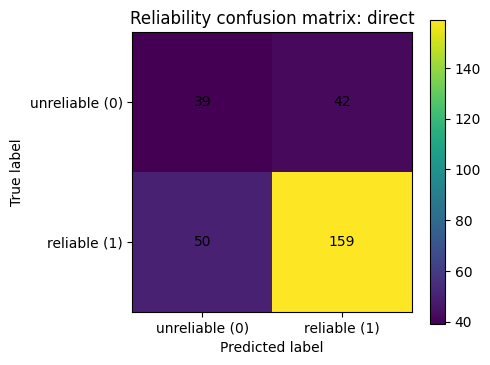


Test classification report: reliability direct / 测试分类报告：可靠性 direct
              precision    recall  f1-score   support

           0     0.4382    0.4815    0.4588        81
           1     0.7910    0.7608    0.7756       209

    accuracy                         0.6828       290
   macro avg     0.6146    0.6211    0.6172       290
weighted avg     0.6925    0.6828    0.6871       290



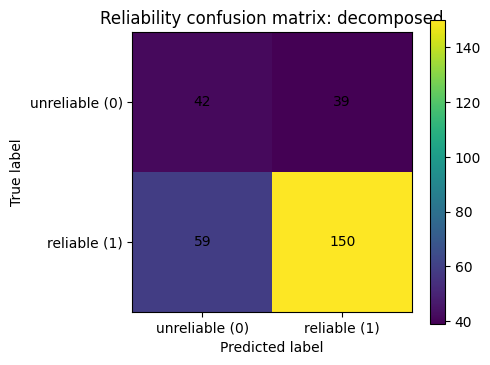


Test classification report: reliability decomposed / 测试分类报告：可靠性 decomposed
              precision    recall  f1-score   support

           0     0.4158    0.5185    0.4615        81
           1     0.7937    0.7177    0.7538       209

    accuracy                         0.6621       290
   macro avg     0.6047    0.6181    0.6077       290
weighted avg     0.6881    0.6621    0.6721       290



In [12]:
figures = []

y_true_test = test_df["binary_reliability"].to_numpy()

for strategy in ["direct", "decomposed"]:
    y_pred_test = test_predictions[f"reliability_{strategy}_pred"].to_numpy()
    matrix = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(matrix)
    ax.set_title(f"Reliability confusion matrix: {strategy}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1], labels=["unreliable (0)", "reliable (1)"])
    ax.set_yticks([0, 1], labels=["unreliable (0)", "reliable (1)"])

    for row in range(2):
        for column in range(2):
            ax.text(column, row, int(matrix[row, column]), ha="center", va="center")

    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    figure_path = RESULTS_DIR / f"confusion_matrix_{strategy}.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()

    print_report(
        f"Test classification report: reliability {strategy} "
        f"/ 测试分类报告：可靠性 {strategy}",
        y_true_test,
        y_pred_test,
    )

## 13. Save reproducible outputs / 保存可复现输出

In [13]:
validation_predictions = pd.concat(
    [
        val_df[
            [
                "case_id",
                "binary_relevancy",
                "binary_faithfulness",
                "binary_reliability",
                "retrieval_config",
            ]
        ].reset_index(drop=True),
        validation_predictions.drop(columns="case_id").reset_index(drop=True),
    ],
    axis=1,
)

test_predictions = pd.concat(
    [
        test_df[
            [
                "case_id",
                "binary_relevancy",
                "binary_faithfulness",
                "binary_reliability",
                "retrieval_config",
            ]
        ].reset_index(drop=True),
        test_predictions.drop(columns="case_id").reset_index(drop=True),
    ],
    axis=1,
)

validation_predictions.to_csv(
    RESULTS_DIR / "validation_predictions.csv",
    index=False,
)

test_predictions.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

majority_results.to_csv(
    RESULTS_DIR / "majority_baselines.csv",
    index=False,
)

selected_model_results.to_csv(
    RESULTS_DIR / "selected_model_results.csv",
    index=False,
)

reliability_comparison.to_csv(
    RESULTS_DIR / "reliability_direct_vs_decomposed.csv",
    index=False,
)

subgroup_results.to_csv(
    RESULTS_DIR / "test_subgroup_results.csv",
    index=False,
)

summary = {
    "seed": SEED,
    "primary_metric": "macro-F1 on binary_reliability",
    "best_configs": best_configs,
    "test_reliability_results": reliability_comparison[
        reliability_comparison["split"] == "test"
    ].to_dict(orient="records"),
}

with open(RESULTS_DIR / "stage2_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

print("Saved files / 已保存文件:")
for path in sorted(RESULTS_DIR.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(ROOT))

Saved files / 已保存文件:
 - results/stage2_tfidf/best_configs.json
 - results/stage2_tfidf/confusion_matrix_decomposed.png
 - results/stage2_tfidf/confusion_matrix_direct.png
 - results/stage2_tfidf/majority_baselines.csv
 - results/stage2_tfidf/models/tfidf_faithfulness.joblib
 - results/stage2_tfidf/models/tfidf_relevancy.joblib
 - results/stage2_tfidf/models/tfidf_reliability.joblib
 - results/stage2_tfidf/reliability_direct_vs_decomposed.csv
 - results/stage2_tfidf/selected_model_results.csv
 - results/stage2_tfidf/stage2_summary.json
 - results/stage2_tfidf/test_predictions.csv
 - results/stage2_tfidf/test_subgroup_results.csv
 - results/stage2_tfidf/validation_grid_results.csv
 - results/stage2_tfidf/validation_predictions.csv


## 14. Interpretation and next step / 结果解释与下一步

Use this notebook as the common lower-bound benchmark for all later methods.  
将本笔记本作为后续所有方法的统一下界基准。

The next method should be an encoder-based classifier using exactly the same:

- train/validation/test files; / 训练集、验证集和测试集文件；
- target definitions; / 目标定义；
- prediction format; / 预测格式；
- validation-only threshold selection; / 仅在验证集上选择阈值；
- direct and decomposed reliability comparison. / 直接与分解式可靠性比较。

Do not modify the test split or tune prompts/models against test metrics.  
不要修改测试集，也不要根据测试指标调整提示词或模型。